# 노트북 02 — 군집화 + 프로파일 해석
## 프로젝트 3: 차종 구성 프로파일링

**목적**: 노트북 01에서 만든 66개 관측치(접근로 11 × 시간대그룹 6)로 군집화를 진행하고,
각 군집의 성격을 해석 가능한 이름으로 정리한다.

**노트북 01에서 확인된 것 (전제)**
- 원본 3개 raw CSV → 평일(공휴일 제외) → 66개 관측치, 셀당 표본 최소 7,668건으로 안정적
- 시간대그룹 6구간 경계는 문헌 근거 + 데이터 변곡점으로 확정됨

**이 노트북에서 반드시 실제 데이터로 확인할 것 (짐작 금지)**
- 분석설계서에서 1차 후보로 뒀던 k=6이 실제로 안정적인지 — 표본 66개라는 제약 하에서
  덴드로그램 근거만으로 정한 것이라 재검증이 필요함
- 최종 k는 실루엣 점수뿐 아니라 부트스트랩 재샘플링 안정성까지 함께 봐서 결정


## 0. 환경 설정 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 20)

BASE_DIR = Path('..')
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
FIG_DIR = BASE_DIR / 'outputs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
pct = pd.read_csv(PROCESSED_DIR / '접근로x시간대_차종구성비.csv')
BAND_ORDER = ['심야(00-04)', '새벽첫차(04-07)', '출근(07-10)', '낮(10-17)', '퇴근(17-20)', '저녁(20-24)']
pct['time_band'] = pd.Categorical(pct['time_band'], categories=BAND_ORDER, ordered=True)

assert pct.shape[0] == 66, f'노트북 01 결과가 66행이 아닙니다: {pct.shape[0]}'
print('OK: 66개 관측치 로드 확인')
pct.head()


OK: 66개 관측치 로드 확인


,AvenueName,time_band,대형버스,대형트럭,소형버스,소형트럭,승용차,오토바이
0,동막교사거리_경기고속삼거리방면,심야(00-04),2.086465,0.981653,0.018112,5.629109,88.645790,2.638871
1,동막교사거리_경기고속삼거리방면,새벽첫차(04-07),24.144502,4.026775,1.255592,13.913247,56.156032,0.503852
2,동막교사거리_경기고속삼거리방면,출근(07-10),7.493949,1.076157,0.329228,11.327489,79.322934,0.450242
3,동막교사거리_경기고속삼거리방면,낮(10-17),6.599564,1.699161,0.215714,7.025392,82.541045,1.919124
4,동막교사거리_경기고속삼거리방면,퇴근(17-20),4.465714,0.762538,0.203968,3.037329,89.845375,1.685075


## 1. 피처 준비

차종 구성비 6개 컬럼을 표준화(평균 0, 분산 1)합니다. 구성비라 이미 0~100 스케일이지만,
차종별로 값의 분산 크기가 달라(예: 승용차는 70~95%대, 오토바이는 0~3%대) 표준화 없이
군집화하면 승용차 비중이 거리 계산을 지배하게 됩니다.

In [3]:
feat_cols = ['승용차', '소형버스', '대형버스', '소형트럭', '대형트럭', '오토바이']
X_raw = pct[feat_cols].values

print('표준화 전 각 차종의 분산:')
print(pd.Series(X_raw.std(axis=0), index=feat_cols).round(2))

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
print('\n표준화 후 각 차종의 분산 (모두 1에 가까워야 정상):')
print(pd.Series(X.std(axis=0), index=feat_cols).round(2))


표준화 전 각 차종의 분산:
승용차     7.08
소형버스    0.55
대형버스    5.82
소형트럭    3.13
대형트럭    0.66
오토바이    0.95
dtype: float64

표준화 후 각 차종의 분산 (모두 1에 가까워야 정상):
승용차     1.0
소형버스    1.0
대형버스    1.0
소형트럭    1.0
대형트럭    1.0
오토바이    1.0
dtype: float64


## 2. 군집수(k) 탐색 — 실루엣 + 부트스트랩 안정성

분석설계서에서는 덴드로그램 병합거리 근거로 k=6을 1차 후보로 뒀습니다. 하지만 66개라는
작은 표본에서는 덴드로그램 근거만으로 부족할 수 있어, **부트스트랩 재샘플링 안정성**을
추가로 확인합니다: 데이터를 복원추출로 다시 뽑아 군집화한 결과가 원래 결과와 얼마나
일치하는지(Adjusted Rand Index, ARI)를 봅니다. ARI가 낮으면 그 k는 우연에 따라 결과가
크게 바뀌는, 신뢰하기 어려운 군집 수라는 뜻입니다.

In [5]:
def bootstrap_stability(X, k, n_boot=30, seed=0):
    rng = np.random.RandomState(seed)
    n = X.shape[0]
    km_full = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X)
    aris = []
    for b in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        km_b = KMeans(n_clusters=k, n_init=10, random_state=b).fit(X[idx])
        pred_full = km_b.predict(X)
        aris.append(adjusted_rand_score(km_full.labels_, pred_full))
    return km_full, np.mean(aris)

results = []
for k in range(2, 9):
    km_full, stability = bootstrap_stability(X, k)
    sil = silhouette_score(X, km_full.labels_)
    sizes = np.bincount(km_full.labels_)
    results.append({
        'k': k, 'silhouette': round(sil, 3), '부트스트랩_안정성(ARI)': round(stability, 3),
        '최소_군집크기': sizes.min(), '군집크기_전체': list(sizes)
    })

result_df = pd.DataFrame(results)
result_df


C:\Users\chpar\anaconda3\envs\TDFP\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\chpar\anaconda3\envs\TDFP\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\chpar\anaconda3\envs\TDFP\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\chpar\anaconda3\envs\TDFP\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans 

,k,silhouette,부트스트랩_안정성(ARI),최소_군집크기,군집크기_전체
0,2,0.386,0.721,11,"[11, 55]"
1,3,0.212,0.465,9,"[27, 9, 30]"
2,4,0.230,0.507,7,"[9, 27, 23, 7]"
3,5,0.219,0.490,1,"[13, 16, 25, 11, 1]"
4,6,0.212,0.532,1,"[19, 18, 5, 15, 8, 1]"
5,7,0.223,0.532,1,"[9, 5, 10, 18, 7, 16, 1]"
6,8,0.249,0.477,1,"[1, 7, 8, 22, 6, 5, 12, 5]"


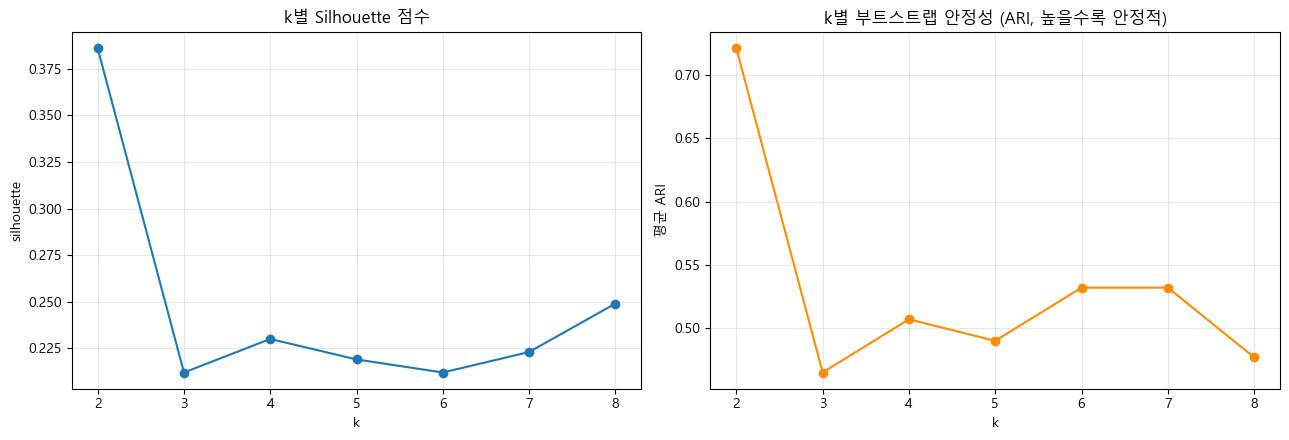


최소 군집크기가 1인 k (=불안정, 단일 관측치가 혼자 군집을 이루는 경우):
[5, 6, 7, 8]


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(result_df['k'], result_df['silhouette'], marker='o')
axes[0].set_title('k별 Silhouette 점수')
axes[0].set_xlabel('k'); axes[0].set_ylabel('silhouette')
axes[0].grid(alpha=0.3)

axes[1].plot(result_df['k'], result_df['부트스트랩_안정성(ARI)'], marker='o', color='darkorange')
axes[1].set_title('k별 부트스트랩 안정성 (ARI, 높을수록 안정적)')
axes[1].set_xlabel('k'); axes[1].set_ylabel('평균 ARI')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'nb02_k선정_진단.png', dpi=150)
plt.show()

print('\n최소 군집크기가 1인 k (=불안정, 단일 관측치가 혼자 군집을 이루는 경우):')
print(result_df.loc[result_df['최소_군집크기'] == 1, 'k'].tolist())


**해석 가이드**
- 최소 군집크기가 1인 k는 후보에서 제외합니다 (관측치 하나가 우연히 혼자 군집을 이루는 것 —
  일반화 불가능한 결과).
- 실루엣이 가장 높은 k라도, 그 분리가 무엇을 기준으로 갈리는지 확인해야 합니다.
  아래 3절에서 k=2가 실제로 무엇을 가르는지 먼저 확인합니다.

## 3. k=2가 실제로 무엇을 가르는지 확인

실루엣·안정성 모두 k=2에서 가장 높게 나올 가능성이 있습니다. 그런데 이게 "지점의 성격"을
가르는 것인지, 아니면 단순히 "시간대"를 가르는 것인지는 확인해봐야 압니다.

In [7]:
km2 = KMeans(n_clusters=2, n_init=20, random_state=42).fit(X)
pct['cluster_k2'] = km2.labels_

print('=== k=2 군집별 평균 차종 구성비 ===')
display(pct.groupby('cluster_k2')[feat_cols].mean().round(2))

print('\n=== k=2 군집과 시간대그룹의 교차표 ===')
display(pd.crosstab(pct['time_band'], pct['cluster_k2']))


=== k=2 군집별 평균 차종 구성비 ===


C:\Users\chpar\anaconda3\envs\TDFP\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,승용차,소형버스,대형버스,소형트럭,대형트럭,오토바이
cluster_k2,,,,,,
0,71.81,1.31,16.29,8.78,1.37,0.45
1,85.83,0.69,7.47,3.78,0.63,1.59



=== k=2 군집과 시간대그룹의 교차표 ===


cluster_k2,0,1
time_band,,
심야(00-04),0,11
새벽첫차(04-07),9,2
출근(07-10),2,9
낮(10-17),0,11
퇴근(17-20),0,11
저녁(20-24),0,11


위 교차표에서 소수 군집이 특정 시간대(예: 새벽첫차)에 쏠려 있다면, k=2는 지점 성격이
아니라 시간대 효과(버스 첫차 등)를 가르는 것입니다. 이 자체가 무의미한 건 아니지만
(어떤 접근로가 버스 노선을 갖고 있는지를 보여주는 신호이므로), 물류축/대중교통축/배달상권처럼
여러 성격을 구분하려는 목적에는 k=2만으로는 부족합니다. 더 큰 k로 넘어가되, 안정적인
k를 선택합니다.

## 4. 최종 k 선정 및 계층적 군집화 교차검증

2절 결과에서 최소 군집크기가 1이 아니면서 안정성(ARI)이 높은 k 중 하나를 선택합니다.
K-means와 별개로 계층적 군집화(Ward)도 같은 k로 잘라서 서로 얼마나 일치하는지 확인합니다.

In [9]:
# 아래 CANDIDATE_K는 위 result_df를 보고 결정합니다. 기본값은 4로 두되,
# 직접 result_df를 보고 다른 값이 더 낫다고 판단되면 이 숫자만 바꿔서 다시 실행하세요.
CANDIDATE_K = 4

km_final = KMeans(n_clusters=CANDIDATE_K, n_init=20, random_state=42).fit(X)
pct['cluster'] = km_final.labels_

Z = linkage(X, method='ward')
hier_labels = fcluster(Z, CANDIDATE_K, criterion='maxclust')
ari_cross = adjusted_rand_score(km_final.labels_, hier_labels)

print(f'k={CANDIDATE_K} 선택')
print(f'K-means vs 계층적 군집화 일치도(ARI): {ari_cross:.3f} (1에 가까울수록 두 방법이 같은 결론)')
print(f'\n군집별 관측치 수: {np.bincount(km_final.labels_)}')


k=4 선택
K-means vs 계층적 군집화 일치도(ARI): 0.280 (1에 가까울수록 두 방법이 같은 결론)

군집별 관측치 수: [ 9 27 23  7]


C:\Users\chpar\anaconda3\envs\TDFP\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


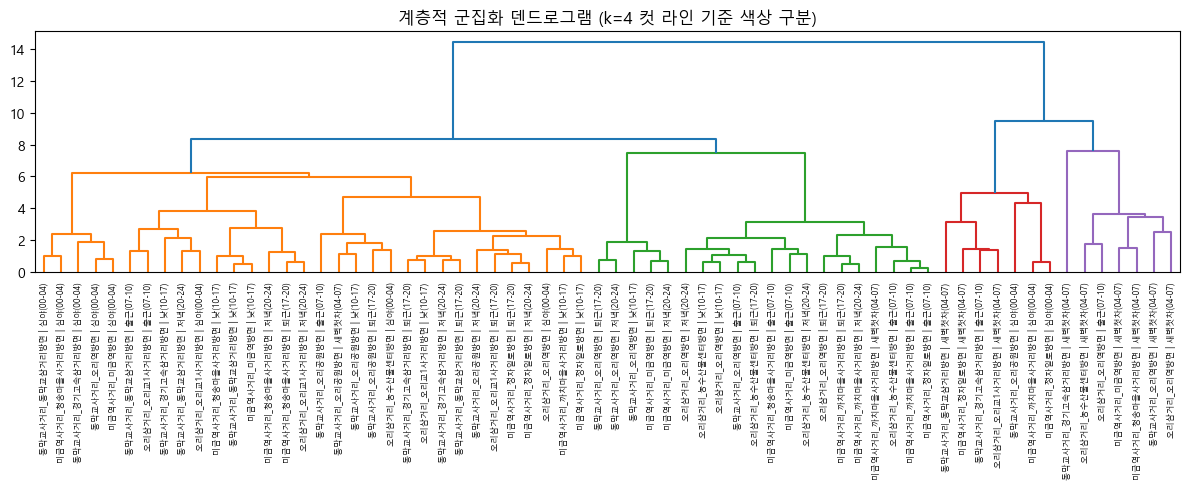

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(Z, labels=(pct['AvenueName'] + ' | ' + pct['time_band'].astype(str)).values,
           leaf_rotation=90, leaf_font_size=6, ax=ax,
           color_threshold=Z[-(CANDIDATE_K-1), 2])
ax.set_title(f'계층적 군집화 덴드로그램 (k={CANDIDATE_K} 컷 라인 기준 색상 구분)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'nb02_덴드로그램.png', dpi=150)
plt.show()


### 시간대 편중 재확인

최종 k에서도 특정 군집이 특정 시간대에 쏠려있는지 다시 확인합니다 (2절과 같은 방식).
쏠림이 있어도 문제는 아니지만, 해석 시 "이 군집=이 시간대 효과"라는 걸 인지하고
이름을 붙여야 합니다.

In [11]:
display(pd.crosstab(pct['time_band'], pct['cluster']))


cluster,0,1,2,3
time_band,,,,
심야(00-04),4,1,6,0
새벽첫차(04-07),3,1,0,7
출근(07-10),1,10,0,0
낮(10-17),1,5,5,0
퇴근(17-20),0,5,6,0
저녁(20-24),0,5,6,0


## 5. 군집 프로파일 해석 및 명명

,승용차,소형버스,대형버스,소형트럭,대형트럭,오토바이,n_관측치
cluster,,,,,,,
0,83.04,0.39,4.62,9.58,1.22,1.15,9
1,87.45,1.01,6.61,3.45,0.58,0.90,27
2,83.73,0.50,9.89,2.99,0.53,2.37,23
3,68.05,1.45,20.33,8.08,1.58,0.49,7


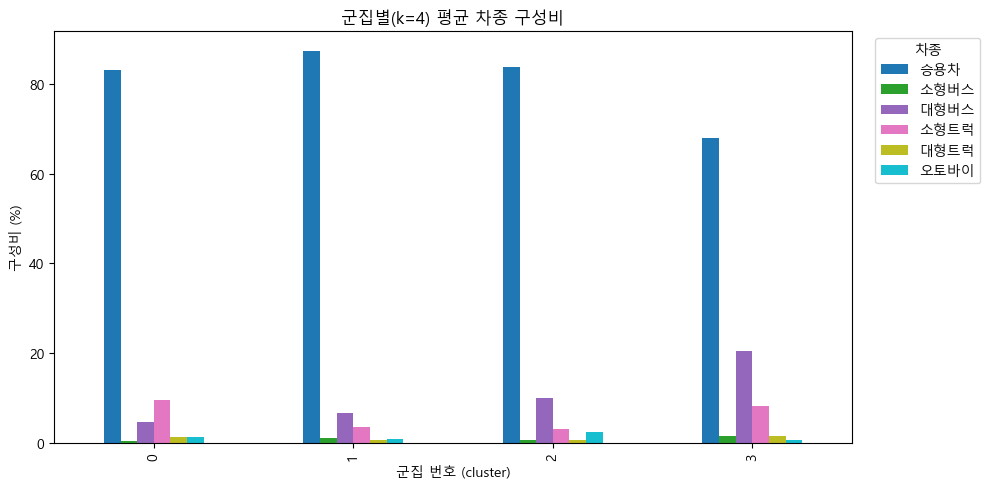

In [17]:
profile = pct.groupby('cluster')[feat_cols].mean().round(2)
profile['n_관측치'] = pct['cluster'].value_counts().sort_index()
display(profile)

fig, ax = plt.subplots(figsize=(10, 5))
profile[feat_cols].plot(kind='bar', ax=ax, colormap='tab10')
ax.set_title(f'군집별(k={CANDIDATE_K}) 평균 차종 구성비')
ax.set_ylabel('구성비 (%)')
ax.set_xlabel('군집 번호 (cluster)')
ax.legend(title='차종', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(FIG_DIR / 'nb02_군집별_프로파일.png', dpi=150)
plt.show()


**군집 이름 붙이기 (직접 채워넣기)**

위 표와 그래프를 보고, 아래 딕셔너리에 각 군집 번호에 해당하는 이름과 근거를 채워넣으세요.
예시:
- 대형버스·소형트럭 비중이 유독 높고 새벽첫차 시간대에 쏠려 있다 → "대중교통축"
- 대형트럭·소형트럭 비중이 시간대 안 가리고 꾸준히 높다 → "물류축"
- 오토바이 비중이 저녁 시간대에 특히 높다 → "배달 상권"
- 승용차 비중이 90%를 넘고 다른 차종은 거의 없다 → "주거 접근로" 등

In [18]:
cluster_names = {
    0: '물류/화물 중심',
    1: '일반/무난한 접근로',
    2: '배달·대중교통 혼합(오후~야간)',
    3: '새벽 첫차 대중교통 극단형',
}
pct['cluster_name'] = pct['cluster'].map(cluster_names)
pct[['AvenueName', 'time_band', 'cluster', 'cluster_name'] + feat_cols].sort_values(['cluster', 'AvenueName'])


,AvenueName,time_band,cluster,cluster_name,승용차,소형버스,대형버스,소형트럭,대형트럭,오토바이
2,동막교사거리_경기고속삼거리방면,출근(07-10),0,물류/화물 중심,79.322934,0.329228,7.493949,11.327489,1.076157,0.450242
3,동막교사거리_경기고속삼거리방면,낮(10-17),0,물류/화물 중심,82.541045,0.215714,6.599564,7.025392,1.699161,1.919124
12,동막교사거리_오리공원방면,심야(00-04),0,물류/화물 중심,81.270077,0.037064,0.786591,12.684293,2.545095,2.676880
13,동막교사거리_오리공원방면,새벽첫차(04-07),0,물류/화물 중심,89.816772,0.595658,1.005067,6.882781,1.343166,0.356556
24,미금역사거리_까치마을사거리방면,심야(00-04),0,물류/화물 중심,85.830632,0.339283,1.314721,10.849860,0.227866,1.437639
...,...,...,...,...,...,...,...,...,...,...
19,동막교사거리_오리역방면,새벽첫차(04-07),3,새벽 첫차 대중교통 극단형,66.887328,2.136428,25.571726,4.106097,0.755189,0.543231
31,미금역사거리_미금역방면,새벽첫차(04-07),3,새벽 첫차 대중교통 극단형,71.847416,1.331509,20.219733,5.712085,0.423736,0.465520
43,미금역사거리_청송마을사거리방면,새벽첫차(04-07),3,새벽 첫차 대중교통 극단형,66.761604,0.818632,23.527440,7.466962,0.688106,0.737257
49,오리삼거리_농수산물센터방면,새벽첫차(04-07),3,새벽 첫차 대중교통 극단형,75.235003,1.424593,14.840299,7.190928,1.164808,0.144369


## 6. 접근로 단위 요약 — 지점별 성격 프로파일

한 접근로가 하루 중 시간대에 따라 다른 군집에 속할 수 있습니다(예: 낮에는 "주거접근로"이지만
새벽첫차 시간대엔 "대중교통축"). 이 자체가 흥미로운 발견이므로, 접근로별로 6개 시간대가
각각 어느 군집에 속하는지 요약합니다.

In [19]:
summary = pct.pivot_table(index='AvenueName', columns='time_band', values='cluster', aggfunc='first', observed=True)
summary = summary[BAND_ORDER]
display(summary)

# 접근로별로 가장 많이 나타나는 군집 = 그 접근로의 '주된 성격'
dominant = pct.groupby('AvenueName')['cluster'].agg(lambda s: s.value_counts().idxmax())
dominant_name = dominant.map(cluster_names)
print('\n=== 접근로별 주된(최빈) 군집 ===')
display(pd.DataFrame({'주된_군집': dominant, '이름': dominant_name}))


time_band,심야(00-04),새벽첫차(04-07),출근(07-10),낮(10-17),퇴근(17-20),저녁(20-24)
AvenueName,,,,,,
동막교사거리_경기고속삼거리방면,2,3,0,0,2,2
동막교사거리_동막교삼거리방면,2,3,1,2,2,2
동막교사거리_오리공원방면,0,0,1,1,1,1
동막교사거리_오리역방면,2,3,1,2,2,2
미금역사거리_까치마을사거리방면,0,1,1,1,1,1
미금역사거리_미금역방면,2,3,1,2,2,2
미금역사거리_정자일로방면,0,0,1,1,1,1
미금역사거리_청송마을사거리방면,2,3,1,2,2,2
오리삼거리_농수산물센터방면,0,3,1,1,1,1



=== 접근로별 주된(최빈) 군집 ===


,주된_군집,이름
AvenueName,,
동막교사거리_경기고속삼거리방면,2,배달·대중교통 혼합(오후~야간)
동막교사거리_동막교삼거리방면,2,배달·대중교통 혼합(오후~야간)
동막교사거리_오리공원방면,1,일반/무난한 접근로
동막교사거리_오리역방면,2,배달·대중교통 혼합(오후~야간)
미금역사거리_까치마을사거리방면,1,일반/무난한 접근로
미금역사거리_미금역방면,2,배달·대중교통 혼합(오후~야간)
미금역사거리_정자일로방면,1,일반/무난한 접근로
미금역사거리_청송마을사거리방면,2,배달·대중교통 혼합(오후~야간)
오리삼거리_농수산물센터방면,1,일반/무난한 접근로


## 7. 검증 — 도메인 상식과 대조

프로젝트 원칙: 지표·군집은 만든 뒤 반드시 적용해서 상식에 맞는지 검증합니다.
예를 들어 '농수산물센터 방면'은 실제로 물류 관련 성격(트럭 비중 높음)으로 분류됐는지,
'미금역/오리역' 방면은 대중교통 관련 성격으로 분류됐는지 직접 확인하세요.

In [20]:
check_points = pct[pct['AvenueName'].str.contains('농수산물센터|미금역|오리역')][
    ['AvenueName', 'time_band', 'cluster', 'cluster_name'] + feat_cols
].sort_values('AvenueName')
display(check_points)

print('''
아래 질문에 스스로 답해보세요 (짐작 말고 위 표 근거로):
1. 농수산물센터 방면은 예상대로 트럭 비중이 높은 군집에 들어갔는가?
2. 미금역/오리역 방면은 예상대로 버스 비중이 높은 군집(특히 새벽첫차)에 들어갔는가?
3. 만약 예상과 다르다면, 그 이유가 무엇인지(진짜 다른 성격인지, 군집 수가 부적절한지) 확인이 필요합니다.
''')


,AvenueName,time_band,cluster,cluster_name,승용차,소형버스,대형버스,소형트럭,대형트럭,오토바이
18,동막교사거리_오리역방면,심야(00-04),2,배달·대중교통 혼합(오후~야간),90.018883,0.122970,2.555336,3.113840,0.285534,3.903436
19,동막교사거리_오리역방면,새벽첫차(04-07),3,새벽 첫차 대중교통 극단형,66.887328,2.136428,25.571726,4.106097,0.755189,0.543231
20,동막교사거리_오리역방면,출근(07-10),1,일반/무난한 접근로,85.323046,1.138402,9.493599,2.967470,0.356732,0.720751
21,동막교사거리_오리역방면,낮(10-17),2,배달·대중교통 혼합(오후~야간),79.543043,1.342530,12.305349,3.506313,0.559697,2.743069
22,동막교사거리_오리역방면,퇴근(17-20),2,배달·대중교통 혼합(오후~야간),79.588168,1.254735,13.852720,1.591528,0.326165,3.386685
23,동막교사거리_오리역방면,저녁(20-24),2,배달·대중교통 혼합(오후~야간),77.383519,1.484723,15.993400,1.267471,0.205877,3.665011
29,미금역사거리_까치마을사거리방면,저녁(20-24),1,일반/무난한 접근로,89.951988,1.131125,6.278291,1.385441,0.152103,1.101052
27,미금역사거리_까치마을사거리방면,낮(10-17),1,일반/무난한 접근로,89.147676,1.035655,4.301539,4.135386,0.227876,1.151866
28,미금역사거리_까치마을사거리방면,퇴근(17-20),1,일반/무난한 접근로,89.837255,1.403262,5.796489,1.765363,0.154366,1.043265
25,미금역사거리_까치마을사거리방면,새벽첫차(04-07),1,일반/무난한 접근로,84.548043,1.127230,6.694428,6.901280,0.510159,0.218861



아래 질문에 스스로 답해보세요 (짐작 말고 위 표 근거로):
1. 농수산물센터 방면은 예상대로 트럭 비중이 높은 군집에 들어갔는가?
2. 미금역/오리역 방면은 예상대로 버스 비중이 높은 군집(특히 새벽첫차)에 들어갔는가?
3. 만약 예상과 다르다면, 그 이유가 무엇인지(진짜 다른 성격인지, 군집 수가 부적절한지) 확인이 필요합니다.



## 8. 결과 저장

In [21]:
pct.to_csv(PROCESSED_DIR / '군집화_결과.csv', index=False, encoding='utf-8-sig')
summary.to_csv(PROCESSED_DIR / '접근로별_시간대별_군집.csv', encoding='utf-8-sig')

print('저장 완료:')
print(f'  {PROCESSED_DIR / "군집화_결과.csv"}')
print(f'  {PROCESSED_DIR / "접근로별_시간대별_군집.csv"}')


저장 완료:
  ..\data\processed\군집화_결과.csv
  ..\data\processed\접근로별_시간대별_군집.csv


## 9. 다음 단계

이 노트북 실행 결과, 특히 다음을 확인한 뒤 채팅방에 공유해주세요:
- 2절 result_df에서 실제로 어떤 k가 안정적으로 나오는지 (제가 사전에 확인한 값과 같은지)
- 5절 군집 이름을 직접 채운 결과
- 7절 도메인 상식 대조에서 예상과 다른 부분이 있었는지

문제없으면 노트북 03(원인 해석 · 의사결정 산출 또는 GitHub/보고서 정리 단계)으로 진행합니다.
